# SpatialMem: Self-Evolving Spatial Reasoning Agent

**Architecture**: Planner → (SKILL invoke) OR (Reasoner + Reflector raw-tool loop) → Reflector.finalize

Two persistent artifacts, accumulated during training and consumed at test:
- **Memory** (declarative): object size / scene scale priors, unsolved cases — `memory/`
- **SKILL** (procedural): folder-based executable tool sequences — `skills/`

Dataset: **VSIBench** (`/mnt/stepeval/datasets/VL_datasets/VSI-Bench/`).


In [1]:
# 用静态后端，避免交互式 widget 卡住格子
%matplotlib inline

# 把 tqdm 强制成纯文本，避免 tqdm.auto 走 ipywidgets 版本（会弹 Renderer 提示并卡住格子）
import sys as _sys, tqdm, tqdm.std, tqdm.auto, tqdm.notebook
tqdm.auto.tqdm = tqdm.std.tqdm          # 之后 `from tqdm.auto import tqdm` 拿到文本版
tqdm.notebook.tqdm = tqdm.std.tqdm
for _m in list(_sys.modules.values()):  # 已经 import 过的 SAM3/DA3 引用也换掉
    if getattr(_m, "tqdm", None) is not None and getattr(_m.tqdm, "__module__", "") == "tqdm.notebook":
        _m.tqdm = tqdm.std.tqdm
import os, sys
from pathlib import Path
import torch

PROJECT_ROOT = Path('/home/zhouruofan/Training-Free/SpatialMem')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault('LLM_BASE_URL', 'http://10.130.138.46:8010/v1')
os.environ.setdefault('LLM_API_KEY',  'sk-ZAJy47c5eid1MW_wjx7Fpg')
os.environ.setdefault('LLM_MODEL',    'qwen3.6-plus')

DEVICE = 'cuda:0'
if torch.cuda.is_available():
    torch.cuda.set_device(DEVICE)
    print('CUDA device:', torch.cuda.get_device_name())
else:
    print('CUDA not available — DA3/SAM3 cannot run on this machine.')

print('Project root:', PROJECT_ROOT)
print('LLM base_url:', os.environ['LLM_BASE_URL'])
print('LLM model   :', os.environ['LLM_MODEL'])

CUDA device: NVIDIA RTX A6000
Project root: /home/zhouruofan/Training-Free/SpatialMem
LLM base_url: http://10.130.138.46:8010/v1
LLM model   : qwen3.6-plus


In [2]:
# LLM client (OpenAI-compatible via httpx). Smoke test the connection.
from agent.llm_client import LLMClient
from agent.config import LLM_BASE_URL, LLM_API_KEY, LLM_MODEL, LLM_TEMPERATURE

llm = LLMClient(
    base_url=LLM_BASE_URL, api_key=LLM_API_KEY,
    model=LLM_MODEL, temperature=LLM_TEMPERATURE,
)
print('LLM test:', llm.chat([{'role': 'user', 'content': 'reply with one word'}]))


LLM test: Okay


In [3]:
# DA3 + SAM3 tool wrappers.
from tools.visual_generation.da3_geometry import DA3GeometryTool
from tools.visual_generation.sam3_segmentation import SAM3SegmentationTool

DA3_MODEL_DIR = os.environ.get('DA3_MODEL_DIR', '/home/zhouruofan/Training-Free/tool_model/DA3NESTED-GIANT-LARGE-1.1')
DA3_REPO      = os.environ.get('DA3_REPO',      '/home/zhouruofan/Training-Free/tool_model/depth-anything-3')
SAM3_REPO     = os.environ.get('SAM3_REPO',     '/home/zhouruofan/Training-Free/tool_model/sam3')
SAM3_CKPT     = os.environ.get('SAM3_CHECKPOINT','/home/zhouruofan/Training-Free/tool_model/sam3.1/sam3.1_multiplex.pt')

da3_tool  = DA3GeometryTool(model_dir=DA3_MODEL_DIR, da3_repo=DA3_REPO, device=DEVICE)
sam3_tool = SAM3SegmentationTool(sam3_repo=SAM3_REPO, checkpoint_path=SAM3_CKPT,
                                  device=DEVICE, confidence_threshold=0.3)
print('DA3 and SAM3 loaded.')

Using device: cuda:0
CUDA device: NVIDIA RTX A6000
[INFO ] using SwiGLU layer as FFN
[INFO ] using MLP layer as FFN
Loading weights from local directory


  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)



loaded /home/zhouruofan/Training-Free/tool_model/sam3.1/sam3.1_multiplex.pt and found missing and/or unexpected keys:
missing_keys=['backbone.vision_backbone.convs.3.conv_1x1.weight', 'backbone.vision_backbone.convs.3.conv_1x1.bias', 'backbone.vision_backbone.convs.3.conv_3x3.weight', 'backbone.vision_backbone.convs.3.conv_3x3.bias']
DA3 and SAM3 loaded.


In [4]:
# Assemble the agent (using VSI-Train-10k for evolution).
from agent.config import ensure_dirs
from agent.data_loader import VSITrain10KDataLoader
from agent.memory import Memory
from agent.orchestrator import Orchestrator
from agent.planner import Planner
from agent.reasoner import Reasoner
from agent.reflector import Reflector
from agent.skill_lib import SkillLib
from agent.tools import ToolRegistry
from agent.train_loop import TrainLoop

ensure_dirs()

loader    = VSITrain10KDataLoader()
memory    = Memory()
skill_lib = SkillLib()
tools     = ToolRegistry(da3_tool=da3_tool, sam3_tool=sam3_tool)
planner   = Planner(llm)
reasoner  = Reasoner(llm)
reflector = Reflector(llm)

orch = Orchestrator(tools, memory, skill_lib, planner, reasoner, reflector, verbose=True)
tl   = TrainLoop(orch, loader, memory, skill_lib, reflector, llm)

print('Agent assembled.')
print('Question types:', loader.question_types())
print('Seed SKILLs   :', [s.name for s in skill_lib.load_all()])

Agent assembled.
Question types: ['absolute_distance', 'appearance_order', 'object_count', 'object_size', 'relative_direction', 'relative_distance', 'room_size']
Seed SKILLs   : ['count_objects', 'judge_direction', 'measure_distance', 'measure_scene_size']


## Single-sample smoke test

Draw a random VSI-Train-10k sample, run the full Planner → (SKILL or raw-tool loop) → Reflector.finalize pipeline.

In [13]:
# Pick a random VSI-Train-10k sample.
import random

question_types = loader.question_types()
qt = random.choice(question_types)
samples = loader.load_task_type(qt, max_samples=30, shuffle=True)
sample = random.choice(samples)

print(f'Question type : {qt}  ({len(samples)} candidates)')
print(f'Sample id     : {sample.id}')
print(f'Task category : {sample.task_category}')
print(f'Answer format : {sample.answer_format}')
print(f'Frames        : {len(sample.image_paths)}')
print(f'Scene         : {sample.scene_id}')
print(f'Question      : {sample.question[:200]}')
print(f'GT answer     : {sample.gt_answer}')

if not sample.image_paths:
    print('\n⚠ No frames found — run extract_frames.py first:')
    print('  cd /home/zhouruofan/datasets/VSI-Train-10k && python extract_frames.py --jobs 8')

Question type : relative_direction  (30 candidates)
Sample id     : 4482
Task category : spatial_relation
Answer format : select
Frames        : 32
Scene         : 42445999_128f
Question      : These are frames of a video.
If I am standing by the dishwasher and facing the table, is the stove to the left or the right of the table?
Options:
A. left
B. right
Answer with the option's letter from
GT answer     : B


In [14]:
# Run the agent with evolution enabled.
result = tl.run_single(sample, evolve=True)

print(f'\n{"="*60}\nFINAL RESULT')
print(f'  Predicted     : {result.predicted_answer!r}')
print(f'  GT            : {result.gt_answer!r}')
print(f'  Correct       : {result.success}')
print(f'  Chosen SKILL  : {result.chosen_skill}')
print(f'  Skills used   : {result.skills_used}')
print(f'  Confidence    : {result.confidence:.2f}')
print(f'  Rounds        : {result.num_rounds}')
print(f'  Time          : {result.duration_seconds:.1f}s')
print(f'  Tool calls    : {[(t["tool_name"], t["success"]) for t in result.tool_calls]}')



Sample 4482 | type=relative_direction (category=spatial_relation)
Q: These are frames of a video.
If I am standing by the dishwasher and facing the table, is the stove to the left or the right of the table?
Options:
A. left
B. right
Answer with the 
GT: B
Retrieved SKILLs: ['judge_direction']
[PLANNER] analysis: The question asks for the relative direction of the stove with respect to the table, from the perspective of someone standing by the dishwasher and facing the table. This requires identifying the 3D positions of the dishwasher, table, and stove, then computing the directional relationship.
[PLANNER] scene_type: kitchen
[PLANNER] chosen_skill: (none — raw-tool loop)
[PLANNER] step 1: depth_estimation params={} | Metric depth maps, camera intrinsics/extrinsics, and a dense 3D point cloud of the kitchen scene.
[PLANNER] step 2: object_segmentation params={'text_prompt': 'white dishwasher under counter', 'object_category': 'dishwasher'} | 2D masks and bounding boxes for the dishwa

In [7]:
# BEV 可视化：从当前上下文的点云生成俯视图，诊断点云重建质量
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# 方法一：直接调用 bev_generation 工具（依赖上面的 run 已跑过 depth_estimation）
frame_paths = tools.context.get('frame_paths', sample.image_paths)
bev_result = tools.execute_tool('bev_generation', {}, frame_paths)
print('BEV tool result:', bev_result)

bev = tools.context.get('bev')
if bev is None:
    print('BEV not in context — re-run depth_estimation first')
else:
    img = bev['bev_display']   # uint8 RGB
    xy_ext = bev['xy_extent']  # (x_meters, z_meters)
    raw_hw = bev['raw_size_hw']

    # 也加载 scene_size 结果做对比
    ss = tools.context.get('scene_size')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 左：BEV 图
    ax = axes[0]
    ax.imshow(img, extent=[0, xy_ext[0], 0, xy_ext[1]], aspect='equal', origin='lower')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Z (m)')
    ax.set_title(f'BEV (point cloud top-down)\n'
                 f'extent: {xy_ext[0]:.2f}m × {xy_ext[1]:.2f}m  |  raw grid: {raw_hw[1]}×{raw_hw[0]}px')

    if ss is not None:
        ext = ss['extent_xyz']
        fa  = ss['floor_area']
        # 画 scene_size 估计的包围盒（归一化到 BEV 范围中心）
        cx, cz = xy_ext[0] / 2, xy_ext[1] / 2
        rect = mpatches.Rectangle(
            (cx - ext[0]/2, cz - ext[2]/2), ext[0], ext[2],
            linewidth=2, edgecolor='red', facecolor='none',
            label=f'scene_size bbox {ext[0]:.2f}×{ext[2]:.2f}m  area={fa:.1f}m²'
        )
        ax.add_patch(rect)
        ax.legend(loc='upper right', fontsize=8)

    # 右：一帧原图参考
    axes[1].imshow(plt.imread(sample.image_paths[len(sample.image_paths)//2]))
    axes[1].set_title(f'Sample {sample.id}  |  GT floor area = {sample.gt_answer} m²\n'
                      f'scene_size_computation = {ss["floor_area"]:.2f} m²' if ss else f'Sample {sample.id}  GT={sample.gt_answer} m²')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    print(f'\nGT floor area : {sample.gt_answer} m²')
    if ss:
        print(f'scene_size    : {ss["floor_area"]:.2f} m²  (bbox {ss["extent_xyz"][0]:.2f}×{ss["extent_xyz"][2]:.2f}m)')
        print(f'BEV point cloud extent: {xy_ext[0]:.2f}×{xy_ext[1]:.2f}m')


BEV tool result: {'tool_name': 'bev_generation', 'params': {}, 'success': False, 'result_summary': '', 'error': 'depth_estimation must be run first'}
BEV not in context — re-run depth_estimation first


## 物体计数 — SAM3 视频追踪模式测试

样本 ID     : 6005
任务类型   : object_count
图片帧数   : 32
场景       : f7da3f0714_compressed

问题：
These are frames of a video.
How many suitcase(s) are in this room?
Please answer the question using a single word or phrase.

正确答案   : 2


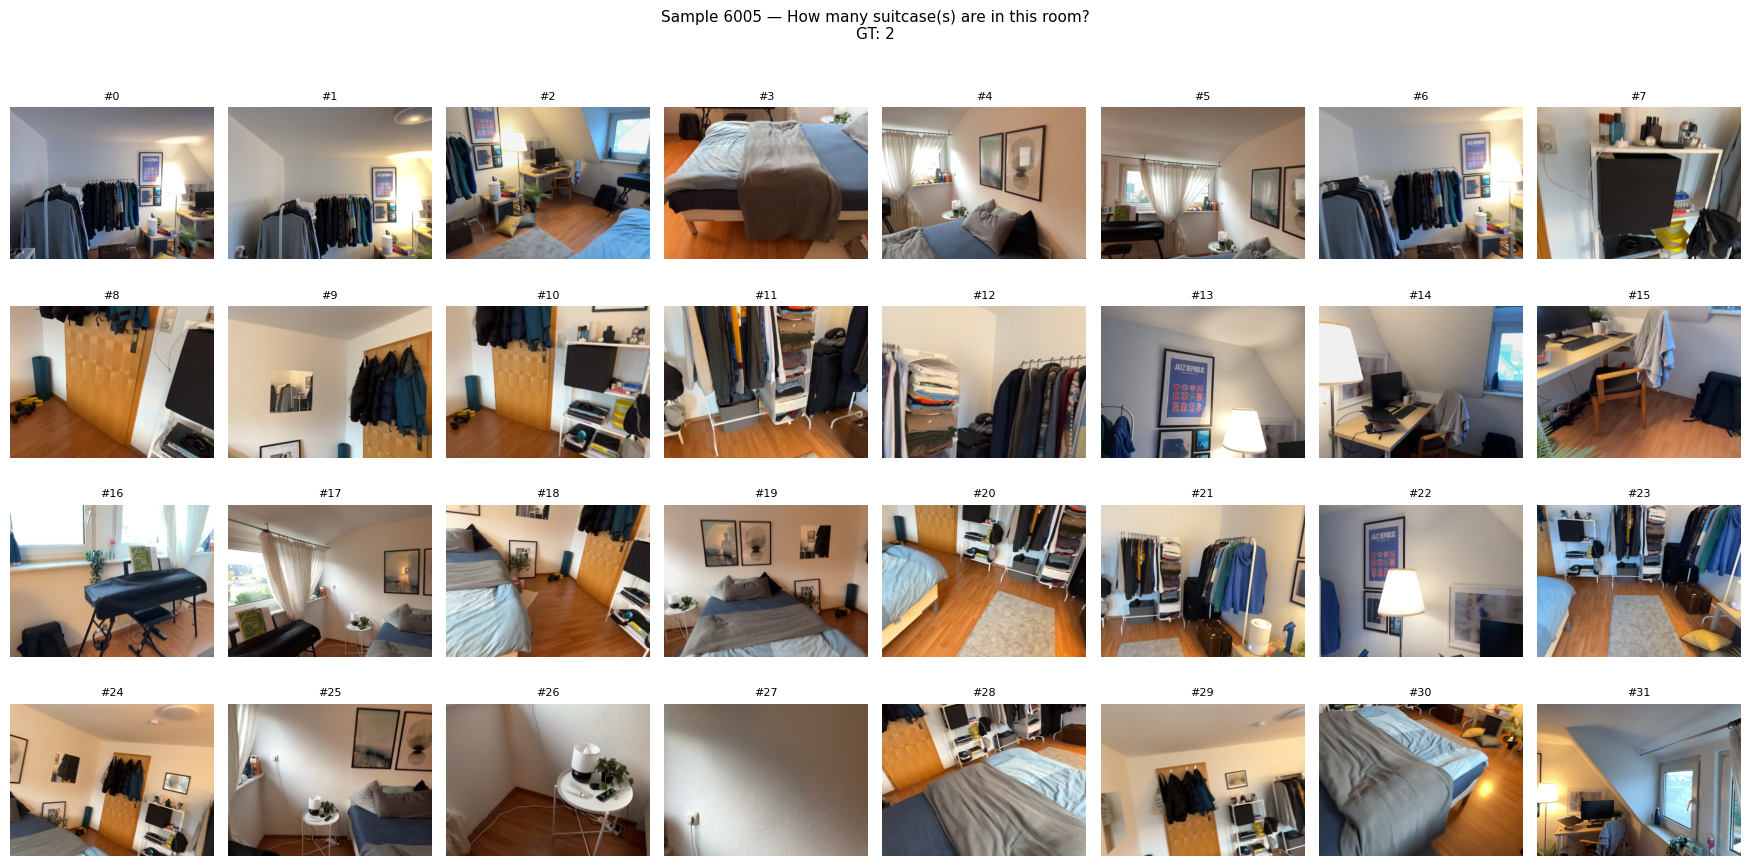

In [44]:
import random
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image as PILImage

# ── 随机加载一个 object_count 样本 ─────────────────────────────────────────
count_samples = loader.load_task_type('object_count', max_samples=500, shuffle=True, seed=random.randint(0, 9999))
count_sample  = random.choice(count_samples)

print(f"样本 ID     : {count_sample.id}")
print(f"任务类型   : {count_sample.task_type}")
print(f"图片帧数   : {len(count_sample.image_paths)}")
print(f"场景       : {count_sample.scene_id}")
print()
print(f"问题：\n{count_sample.question}")
print()
print(f"正确答案   : {count_sample.gt_answer}")

# ── 展示全部 32 帧 ──────────────────────────────────────────────────────────
n_frames = len(count_sample.image_paths)
cols = 8
rows = math.ceil(n_frames / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
axes = axes.ravel()

for i, path in enumerate(count_sample.image_paths):
    img = PILImage.open(path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(f"#{i}", fontsize=8)
    axes[i].axis("off")

for j in range(n_frames, len(axes)):
    axes[j].axis("off")

fig.suptitle(
    f'Sample {count_sample.id} — {count_sample.question.splitlines()[1] if len(count_sample.question.splitlines()) > 1 else count_sample.question[:80]}\n'
    f'GT: {count_sample.gt_answer}',
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

目标物体   : 'suitcase'
正确答案   : 2
帧数       : 32

正在加载 SAM3 视频预测器并追踪……（首次调用会构建视频模型，稍等）


INFO 2026-07-15 01:54:16,564 2109419 sam3_base_predictor.py: 146: started new session 921987cf-41ed-4388-8873-e4beb85b51a1
INFO 2026-07-15 01:54:16,566 2109419 sam3_multiplex_tracking.py:1678: Running add_prompt on frame 0
INFO 2026-07-15 01:54:16,958 2109419 sam3_multiplex_tracking.py:2319: Running full VG propagation (reverse=False).


  [SAM3 video] add_prompt frame 0: 1 'suitcase' detected


propagate_in_video: 100%|██████████| 32/32 [00:05<00:00,  6.07it/s]
INFO 2026-07-15 01:54:22,236 2109419 sam3_multiplex_tracking.py: 581: Bucket utilization rate: 31.25%, subscription rate: 500.00%
INFO 2026-07-15 01:54:22,238 2109419 sam3_multiplex_tracking.py:2319: Running full VG propagation (reverse=True).
propagate_in_video: 0it [00:00, ?it/s]
INFO 2026-07-15 01:54:22,241 2109419 sam3_multiplex_tracking.py: 581: Bucket utilization rate: 31.25%, subscription rate: 500.00%
INFO 2026-07-15 01:54:22,241 2109419 sam3_base_predictor.py: 305: propagation ended in session 921987cf-41ed-4388-8873-e4beb85b51a1
INFO 2026-07-15 01:54:22,695 2109419 sam3_base_predictor.py: 408: removed session 921987cf-41ed-4388-8873-e4beb85b51a1
  cmap = cm.get_cmap("tab10")




追踪到的唯一实例数 : 5
正确答案           : 2
结果               : ✗ 错误

各帧检测到的实例 ID：
  帧  0: [0]
  帧  2: [0]
  帧  6: [0]
  帧 11: [0, 1]
  帧 12: [1]
  帧 21: [0, 2, 3]
  帧 23: [0, 2, 3]
  帧 30: [4]


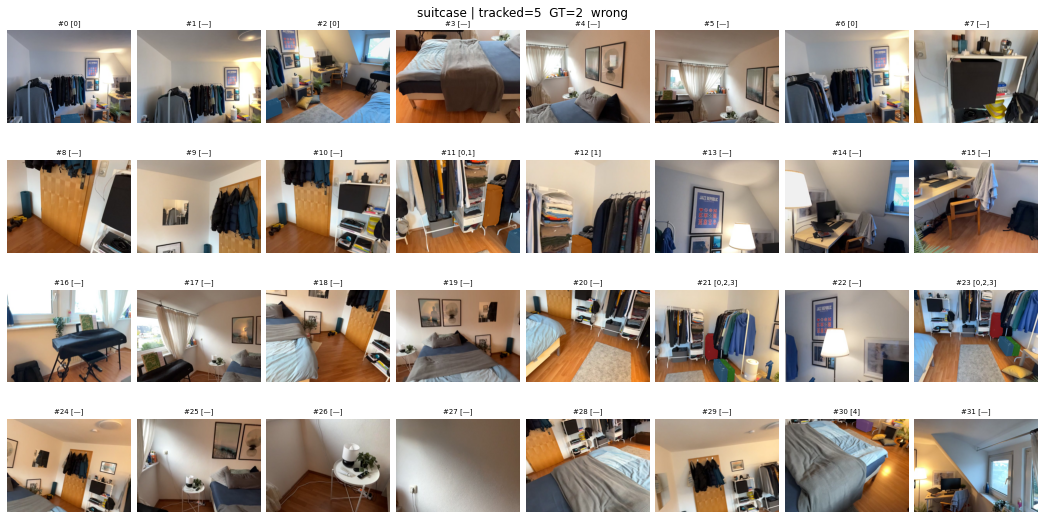

In [45]:
import re

# ── 从问题里提取查找目标（"How many <target>(s) are in this room?"）───────────
question_text = count_sample.question
match = re.search(r'How many\s+([\w\s]+?)\(s\)', question_text, re.IGNORECASE)
if match:
    object_name = match.group(1).strip().lower()
else:
    # 备选：取问题第二行，否则让用户手动改
    object_name = "chair"
    print(f"[警告] 未能自动解析目标物体，使用默认值: {object_name!r}")

print(f"目标物体   : {object_name!r}")
print(f"正确答案   : {count_sample.gt_answer}")
print(f"帧数       : {len(count_sample.image_paths)}")
print()
print("正在加载 SAM3 视频预测器并追踪……（首次调用会构建视频模型，稍等）")

# ── 调用视频追踪 ────────────────────────────────────────────────────────────
track_result = sam3_tool.segment_video_track(
    frame_paths=count_sample.image_paths,
    text_prompt=object_name,
)

predicted = track_result["total_count"]
gt        = int(count_sample.gt_answer)
correct   = (predicted == gt)

print(f"\n{'='*50}")
print(f"追踪到的唯一实例数 : {predicted}")
print(f"正确答案           : {gt}")
print(f"结果               : {'✓ 正确' if correct else '✗ 错误'}")
print(f"{'='*50}")
print(f"\n各帧检测到的实例 ID：")
for i, fr in enumerate(track_result["per_frame"]):
    if fr["obj_ids"]:
        print(f"  帧 {i:2d}: {fr['obj_ids']}")

# ── 可视化：每帧叠加 mask ─────────────────────────────────────────────────
import numpy as np
import matplotlib.cm as cm

n_frames = len(count_sample.image_paths)
cols = 8
rows = math.ceil(n_frames / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 1.8),
                         dpi=72, constrained_layout=True)
axes = axes.ravel()

cmap = cm.get_cmap("tab10")
all_ids = track_result["unique_obj_ids"]
id_to_color = {oid: cmap(i % 10)[:3] for i, oid in enumerate(all_ids)}

for fi, path in enumerate(count_sample.image_paths):
    ax = axes[fi]
    img_np = np.array(PILImage.open(path).convert("RGB"))
    fr = track_result["per_frame"][fi]

    overlay = img_np.copy().astype(float)
    for j, oid in enumerate(fr["obj_ids"]):
        mask = fr["masks"][j]
        if mask.shape != img_np.shape[:2]:
            from PIL import Image as _PI
            mask = np.array(_PI.fromarray(mask).resize(
                (img_np.shape[1], img_np.shape[0]), _PI.NEAREST))
        color = np.array(id_to_color[oid]) * 255
        overlay[mask] = overlay[mask] * 0.45 + color * 0.55

    _disp = PILImage.fromarray(overlay.clip(0, 255).astype(np.uint8))
    _disp.thumbnail((360, 360))   # shrink for display so the figure PNG stays small
    ax.imshow(np.asarray(_disp))
    label = ",".join(str(o) for o in fr["obj_ids"]) if fr["obj_ids"] else "—"
    ax.set_title(f"#{fi} [{label}]", fontsize=7)
    ax.axis("off")

for j in range(n_frames, len(axes)):
    axes[j].axis("off")

status = "correct" if correct else "wrong"
fig.suptitle(
    f'{object_name} | tracked={predicted}  GT={gt}  {status}',
    fontsize=12, y=1.01,
)
plt.show()
plt.close(fig)   # free the figure so it doesn't block/accumulate

In [39]:
import importlib, tools.code_execution.instance_3d_localization as m; importlib.reload(m)

<module 'tools.code_execution.instance_3d_localization' from '/home/zhouruofan/Training-Free/SpatialMem/tools/code_execution/instance_3d_localization.py'>

In [46]:
# ── 3D 反投影 + 两级合并：把视频 track 合成唯一目标物体 ─────────────────────
# 依赖：cell 11 的 track_result / object_name / count_sample，cell 3 的 da3_tool
import numpy as np
from pathlib import Path
from PIL import Image as PILImage
from tools.code_execution.instance_3d_localization import compute_instance_3d_positions

# 1) DA3 深度 + 相机内外参（当前样本的帧）
print("正在 estimate depth（DA3）……")
da3 = da3_tool.run(
    frame_paths=count_sample.image_paths,
    output_dir=Path("outputs/count_localize"),
    process_res=504, save_depth_vis=False,
    infer_gs=False,   # 只需深度+内外参，跳过最耗时的 3D Gaussian Splatting
)
depth, intr, extr = da3["depth"], da3.get("intrinsics"), da3.get("extrinsics")
assert intr is not None and extr is not None, "DA3 未返回内外参，无法反投影"

# 2) track_result -> seg_results（带 obj_ids，mask 缩放回原图分辨率）
with PILImage.open(count_sample.image_paths[0]) as _im:
    orig_w, orig_h = _im.size

seg_results = []
for fr in track_result["per_frame"]:
    n = len(fr["scores"])
    if n == 0:
        seg_results.append({"masks": np.empty((0, orig_h, orig_w), bool),
                            "boxes": np.empty((0, 4), np.float32),
                            "scores": np.empty((0,), np.float32),
                            "obj_ids": [], "labels": [], "image_size": (orig_w, orig_h)})
        continue
    masks = np.asarray(fr["masks"], bool)
    if masks.shape[1:] != (orig_h, orig_w):
        masks = np.stack([np.array(PILImage.fromarray(m).resize((orig_w, orig_h), PILImage.NEAREST))
                          for m in masks])
    seg_results.append({"masks": masks,
                        "boxes": np.asarray(fr["boxes"], np.float32),
                        "scores": np.asarray(fr["scores"], np.float32),
                        "obj_ids": [int(o) for o in fr["obj_ids"]],
                        "labels": [object_name] * n,
                        "image_size": (orig_w, orig_h)})

# 3) 反投影 + 两级合并（Stage A 信任 obj_id，Stage B 严格 3D 判据）
r3d = compute_instance_3d_positions(seg_results, depth, intr, extr)

# 4) 每个最终目标物体合并了哪些原始 video obj_id
f2g = r3d["frame_to_global"]
cluster_to_ids = {}
for fi, fr in enumerate(seg_results):
    for li, oid in enumerate(fr["obj_ids"]):
        ci = int(f2g[fi][li])
        if ci >= 0:
            cluster_to_ids.setdefault(ci, set()).add(oid)

k = len(r3d["obj_id_list"])
print()
print("=" * 56)
print(f"视频追踪原始 track 数 : {track_result['total_count']}  (ids={track_result['unique_obj_ids']})")
print(f"3D 合并后目标物体数   : {k}")
gt = int(count_sample.gt_answer)
print(f"正确答案             : {gt}   {'OK' if k == gt else 'X'}")
print("=" * 56)
for ci in r3d["obj_id_list"]:
    pos  = r3d["merged_positions"][ci]
    size = r3d["merged_bbox_size"][ci]
    ids  = sorted(cluster_to_ids.get(ci, set()))
    print(f"目标物体 #{ci}: 合并 track ids = {ids}")
    print(f"           3D中心 = ({pos[0]:.2f}, {pos[1]:.2f}, {pos[2]:.2f}) m   "
          f"包围盒 = ({size[0]:.2f} x {size[1]:.2f} x {size[2]:.2f}) m")


正在 estimate depth（DA3）……
[INFO ] Processed Images Done taking 0.08065533638000488 seconds. Shape:  torch.Size([32, 3, 378, 504])
[INFO ] Selecting reference view using strategy: saddle_balanced
[INFO ] Model Forward Pass Done. Time: 3.220811605453491 seconds
[INFO ] Conversion to Prediction Done. Time: 0.011214971542358398 seconds

视频追踪原始 track 数 : 5  (ids=[0, 1, 2, 3, 4])
3D 合并后目标物体数   : 2
正确答案             : 2   OK
目标物体 #0: 合并 track ids = [0, 2, 4]
           3D中心 = (0.58, -1.39, 3.15) m   包围盒 = (0.59 x 0.53 x 0.43) m
目标物体 #1: 合并 track ids = [1, 3]
           3D中心 = (0.08, -2.01, 3.41) m   包围盒 = (0.46 x 0.81 x 0.54) m


In [38]:
import numpy as np
from tools.code_execution.instance_3d_localization import (
    _back_project_region, _compute_3d_bbox, _aabb_iou_ios, _rescale_box, _as_homogeneous)

# 按 track_id 聚合每个 track 的真实 3D 包围盒
track_box = {}   # oid -> [min(3), max(3)]
for fi, seg in enumerate(seg_results):
    n = len(seg["scores"])
    if n == 0:
        continue
    d_map, K = depth[fi], intr[fi]
    c2w = np.linalg.inv(_as_homogeneous(extr[fi]))
    d_h, d_w = d_map.shape
    masks, boxes, oids = seg.get("masks"), seg.get("boxes"), seg["obj_ids"]
    for i in range(n):
        mask_i = masks[i] if masks is not None else None
        box_i = _rescale_box(boxes[i], d_w, d_h, seg.get("image_size")) if (mask_i is None and boxes is not None) else None
        pts = _back_project_region(mask_i, box_i, d_map, K, c2w, d_h, d_w)
        if pts is None:
            continue
        lo, hi, _ = _compute_3d_bbox(pts, 2.0)
        o = oids[i]
        if o not in track_box:
            track_box[o] = [lo.copy(), hi.copy()]
        else:
            track_box[o][0] = np.minimum(track_box[o][0], lo)
            track_box[o][1] = np.maximum(track_box[o][1], hi)

def box_of(oids):
    lo = np.min([track_box[o][0] for o in oids], axis=0)
    hi = np.max([track_box[o][1] for o in oids], axis=0)
    return lo, hi

lo_a, hi_a = box_of([13])
lo_b, hi_b = box_of([1, 12])
iou, ios = _aabb_iou_ios(lo_a, hi_a, lo_b, hi_b)
ca, cb = 0.5*(lo_a+hi_a), 0.5*(lo_b+hi_b)
dist = float(np.linalg.norm(ca-cb))
diag_a, diag_b = np.linalg.norm(hi_a-lo_a), np.linalg.norm(hi_b-lo_b)
cthr = 0.30 * min(diag_a, diag_b)

print(f"track 13    box: min={lo_a.round(2)}  max={hi_a.round(2)}")
print(f"cluster[1,12] box: min={lo_b.round(2)}  max={hi_b.round(2)}")
print(f"IoU = {iou:.3f}   (阈值 0.30)")
print(f"IoS = {ios:.3f}   (阈值 0.60)")
print(f"质心距离 = {dist:.3f} m   (质心阈值 = 0.30×{min(diag_a,diag_b):.2f} = {cthr:.3f} m)")
print("→ 合并需满足任一: IoU≥0.30 或 IoS≥0.60 或 质心距离≤质心阈值")


track 13    box: min=[-0.13  0.47  1.12]  max=[-0.    0.69  1.61]
cluster[1,12] box: min=[-0.44  0.36  0.64]  max=[0.22 1.07 1.29]
IoU = 0.016   (阈值 0.30)
IoS = 0.359   (阈值 0.60)
质心距离 = 0.424 m   (质心阈值 = 0.30×0.55 = 0.166 m)
→ 合并需满足任一: IoU≥0.30 或 IoS≥0.60 或 质心距离≤质心阈值
